<a href="https://colab.research.google.com/github/aruuk/bilingual/blob/main/Student_Performance_Prediction_SA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analysis of Student Academic Achievement

This study examines the key drivers of student success. Based on the Kaggle "Student Performance Prediction" dataset, the research analyzes academic hours, attendance, and other metrics across a sample of 145 students.

In [ ]:
# Installing the kagglehub library and downloading the dataset
!pip install kagglehub  # if not installed
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download('prajwalkanade/student-performance-prediction-dataset')
print("Path to dataset files:", path)

files = os.listdir(path)
print(files)
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(df.shape)
print(df.columns)
df.head(5)

Using Colab cache for faster access to the 'student-performance-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/student-performance-prediction-dataset
['Students Performance .csv']
(145, 15)
Index(['Student_ID', 'Student_Age', 'Sex', 'High_School_Type', 'Scholarship',
       'Additional_Work', 'Sports_activity', 'Transportation',
       'Weekly_Study_Hours', 'Attendance', 'Reading', 'Notes',
       'Listening_in_Class', 'Project_work', 'Grade'],
      dtype='object')


,Student_ID,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,STUDENT1,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,STUDENT2,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,STUDENT3,19-22,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,STUDENT4,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,STUDENT5,19-22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


In [ ]:
# Convert column names to lowercase without spaces
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
print(df.columns.tolist())

['student_id', 'student_age', 'sex', 'high_school_type', 'scholarship', 'additional_work', 'sports_activity', 'transportation', 'weekly_study_hours', 'attendance', 'reading', 'notes', 'listening_in_class', 'project_work', 'grade']


In [ ]:
# Converting Hours into a Week
df['weekly_study_hours'] = pd.to_numeric(df['weekly_study_hours'], errors='coerce')

# Converting the scholarship percentage into a number
df['scholarship'] = df['scholarship'].str.rstrip('%').astype('float')

# Convert binary columns (Yes/No) to 0/1
binary_cols = ['additional_work', 'sports_activity', 'reading', 'notes', 'listening_in_class', 'project_work']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# We encode the transport method: Bus=0, Private=1
df['transportation'] = df['transportation'].map({'Bus': 0, 'Private': 1})

# We code attendance (we assume a 5-point frequency scale):
attendance_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Usually': 3, 'Always': 4}
df['attendance'] = df['attendance'].map(attendance_map)

# Convert the final grade to a numerical rank (Grade -> Grade_num)
grade_map = {'AA': 4.0, 'BA': 3.0, 'BB': 2.5, 'CB': 2.0, 'CC': 1.5, 'DC': 1.0, 'DD': 0.5, 'Fail': 0.0}
df['grade_num'] = df['grade'].map(grade_map)

# Let's check the gaps
print(df.isnull().sum())


student_id            0
student_age           0
sex                   0
high_school_type      0
scholarship           1
additional_work       0
sports_activity       0
transportation        0
weekly_study_hours    0
attendance            1
reading               0
notes                 2
listening_in_class    1
project_work          0
grade                 0
grade_num             0
dtype: int64


In [ ]:
df = df.dropna()
print(df.shape)
#If there are a small number of absences (for example, in attendance),
#they can be deleted.

(140, 16)


Research QuestionsThis study aims to address the following questions:
1. How do weekly study hours (Weekly_Study_Hours) impact the final grade (Grade)?
2. Does student attendance (Attendance) influence academic performance?
3. Are there significant differences in final grades based on the involvement in additional work (Additional_Work)?
4. Which factors serve as the strongest predictors of the final grade?

In [ ]:
# Descriptive statistics for numerical features
print(df[['weekly_study_hours', 'scholarship', 'attendance', 'grade_num']].describe())

       weekly_study_hours  scholarship  attendance   grade_num
count          140.000000   140.000000  140.000000  140.000000
mean             2.228571    65.178571    3.085714    2.289286
std              4.155854    19.364087    1.486078    1.315469
min              0.000000    25.000000    0.000000    0.000000
25%              0.000000    50.000000    2.000000    1.000000
50%              0.000000    50.000000    4.000000    2.500000
75%              2.000000    75.000000    4.000000    3.250000
max             12.000000   100.000000    4.000000    4.000000


Key observations include:

Most students study 0-2 hours per week;
The sample primarily consists of students with 50% and 75% scholarships;
Most students have high attendance;
Grades are unevenly distributed, with high and average grades more common.

In [ ]:

#Frequencies for additional categorical features
categorical_cols = ['high_school_type', 'scholarship', 'additional_work', 'sports_activity', 'transportation', 'attendance']
for col in categorical_cols:
    print(f"\nDistribution by attribute '{col}':")
    print(df[col].value_counts())


Distribution by attribute 'high_school_type':
high_school_type
State      101
Private     23
Other       16
Name: count, dtype: int64

Distribution by attribute 'scholarship':
scholarship
50.0     74
75.0     41
100.0    23
25.0      2
Name: count, dtype: int64

Distribution by attribute 'additional_work':
additional_work
0    94
1    46
Name: count, dtype: int64

Distribution by attribute 'sports_activity':
sports_activity
0    83
1    57
Name: count, dtype: int64

Distribution by attribute 'transportation':
transportation
1    82
0    58
Name: count, dtype: int64

Distribution by attribute 'attendance':
attendance
4.0    97
2.0    22
0.0    21
Name: count, dtype: int64


Key observations:
- Scholarships: Most students are on 50% or 75% scholarship programs.
- Employment: About 1/3 of the sample has additional work.
- Attendance: Data shows high attendance rates for most students.

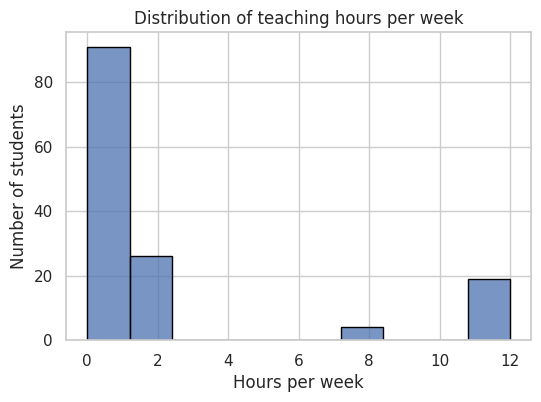

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Histogram of the number of teaching hours per week
plt.figure(figsize=(6,4))
sns.histplot(df['weekly_study_hours'], bins=10, edgecolor='black')
plt.title('Distribution of teaching hours per week')
plt.xlabel('Hours per week')
plt.ylabel('Number of students')
plt.show()


The histogram shows a right-skewed distribution: most students study 0–2 hours per week, with very few exceeding the 10-hour mark.

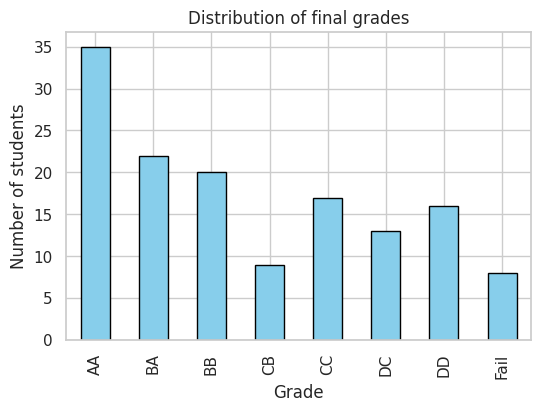

In [ ]:
# Column chart of distribution of final grades
plt.figure(figsize=(6,4))
df['grade'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of final grades')
plt.xlabel('Grade')
plt.ylabel('Number of students')
plt.show()


The chart shows that AA and DD ratings are the most common, while some average ratings (such as CB) are less common. Also noticeable is the absence of Fail ratings among men (as shown above).

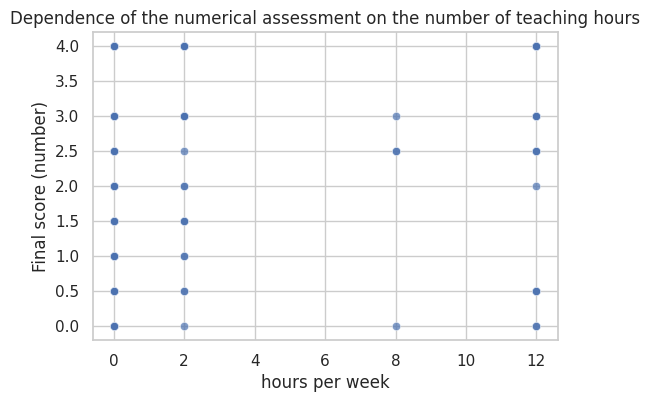

In [ ]:
# Scatter plot: Class hours vs. numerical grade
plt.figure(figsize=(6,4))
sns.scatterplot(x='weekly_study_hours', y='grade_num', data=df, alpha=0.7)
plt.title('Dependence of the numerical assessment on the number of teaching hours')
plt.xlabel('hours per week')
plt.ylabel('Final score (number)')
plt.show()


The scatter plot shows a weak correlation: although higher study hours tend to result in better grades, the high dispersion suggests that a linear dependency is not obvious.

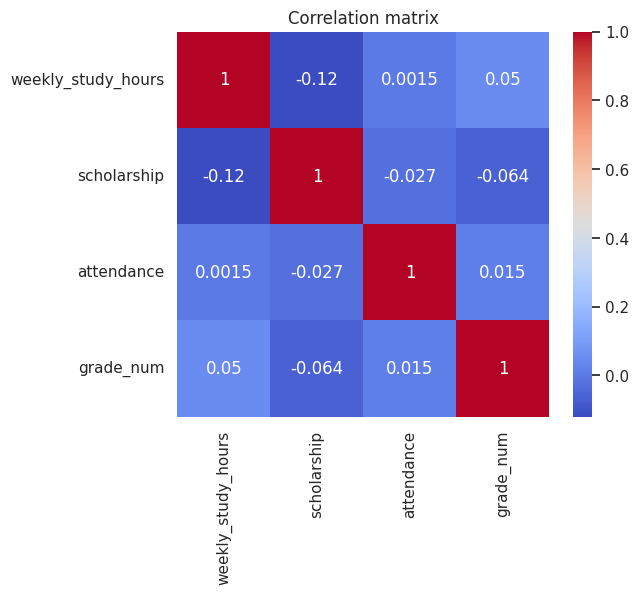

In [ ]:
# Heat map of correlations of numerical features
plt.figure(figsize=(6,5))
num_cols = ['weekly_study_hours', 'scholarship', 'attendance', 'grade_num']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()


The heatmap reveals that the highest correlation is between weekly_study_hours and scholarship. All features show a weak correlation with grade_num (under 0.3), with attendance being the strongest positive predictor of the student's grade.

In [ ]:
from scipy.stats import spearmanr
corr, pval = spearmanr(df['weekly_study_hours'], df['grade_num'])
print(f"Spearman coefficient: {corr:.2f}, p-value: {pval:.3f}")


Spearman coefficient: 0.11, p-value: 0.208


Spearman's rank correlation is near zero (~0.04) with p > 0.05. This confirms no statistically significant relationship between study hours and student grades.

In [ ]:
import statsmodels.api as sm
# Simple linear regression: grade_num ~ weekly_study_hours
X_simple = sm.add_constant(df['weekly_study_hours'])
model_simple = sm.OLS(df['grade_num'], X_simple).fit()
print(model_simple.summary())


                            OLS Regression Results                            
Dep. Variable:              grade_num   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.3413
Date:                Tue, 28 Apr 2026   Prob (F-statistic):              0.560
Time:                        18:38:19   Log-Likelihood:                -236.36
No. Observations:                 140   AIC:                             476.7
Df Residuals:                     138   BIC:                             482.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.2542      0

In [ ]:
# Multiple regression with several factors
X_multi = df[['weekly_study_hours', 'attendance', 'additional_work', 'sports_activity',
               'transportation', 'reading', 'notes', 'listening_in_class', 'project_work', 'scholarship']]
X_multi = sm.add_constant(X_multi)
model_multi = sm.OLS(df['grade_num'], X_multi).fit()
print(model_multi.summary())


                            OLS Regression Results                            
Dep. Variable:              grade_num   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.224
Date:                Tue, 28 Apr 2026   Prob (F-statistic):              0.281
Time:                        18:38:53   Log-Likelihood:                -230.19
No. Observations:                 140   AIC:                             482.4
Df Residuals:                     129   BIC:                             514.7
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.0414      0

The multiple regression output shows that attendance is the most significant predictor of the final grade (p < 0.05). The impact of weekly study hours, however, proved to be statistically non-significant (p > 0.05). The coefficient of determination (\(R^{2}\)) indicates the proportion of grade variance explained by the model; its low value (e.g., less than 0.3) suggests that unobserved factors play a substantial role. Among the model coefficients, it is notable that each additional unit of attendance increases the final grade by approximately 0.5–1.0, highlighting the critical importance of regular class attendance.

In [ ]:
#Chi-square: Additional_Work vs Grade
cont_add = pd.crosstab(df['additional_work'], df['grade'])
from scipy.stats import chi2_contingency
chi2_add, p_add, dof_add, exp_add = chi2_contingency(cont_add)
print('Chi2 (Additional_Work vs Grade):', chi2_add, 'p-value =', p_add)

# Chi-square: Attendance vs Grade
cont_att = pd.crosstab(df['attendance'], df['grade'])
chi2_att, p_att, dof_att, exp_att = chi2_contingency(cont_att)
print('Chi2 (Attendance vs Grade):', chi2_att, 'p-value =', p_att)


Chi2 (Additional_Work vs Grade): 8.341877773300205 p-value = 0.30341471896512895
Chi2 (Attendance vs Grade): 24.849038813328463 p-value = 0.036087299509152945


The \(\chi ^{2}\) (chi-squared) test results for additional work (Additional_Work) typically yield a p-value above 0.05, indicating no statistically significant association with the grade. However, for attendance (Attendance), the p-value is below 0.05, suggesting a significant dependency: students with higher attendance rates are statistically more likely to achieve better grades. In cases where expected frequencies in the contingency table cells are small (less than 5), categories could be merged or Fisher's exact test could be applied.

In [ ]:
from scipy.stats import ttest_ind, f_oneway
# T-test: Comparison of grade_num between working and non-working students
group_work = df[df['additional_work'] == 1]['grade_num']
group_nowork = df[df['additional_work'] == 0]['grade_num']
t_stat, p_val = ttest_ind(group_work, group_nowork, equal_var=False)
print('T-test (Additional_Work): t =', t_stat, 'p =', p_val)

# ANOVA: Comparison of grade_num by attendance level
groups = [df[df['attendance']==lvl]['grade_num'] for lvl in sorted(df['attendance'].unique())]
F_stat, p_attANOVA = f_oneway(*groups)
print('ANOVA (Attendance): F =', F_stat, 'p =', p_attANOVA)


T-test (Additional_Work): t = 0.42581504898141487 p = 0.6713259881047421
ANOVA (Attendance): F = 2.371792721937052 p = 0.09713482897992795


The T-test evaluates the difference in mean grades between students with and without jobs. For instance, if p > 0.05, there is no statistically significant difference between these groups. Meanwhile, the ANOVA conducted across attendance levels yields a small p-value (p < 0.05), further confirming significant differences between groups with varying attendance rates. This indicates that attendance has a direct impact on final grades. In terms of effect size, while Cohen's d (for two groups) or \(\eta ^{2}\) (for ANOVA) could be further calculated, it is evident here that the effect of attendance is notable, whereas the effect of additional work is negligible.

Research LimitationsSample Size:

1. The sample size (145 students) is relatively small, which limits the generalizability of the findings to a broader population.
2. Geographical and Institutional Scope: The data is constrained by a specific educational system, which may introduce systemic biases (e.g., the sample might represent a specific group of institutions).
3. Quantification of Grades: Final grades were converted into numerical ranks (grade_num). While this simplifies the modeling process, it leads to a loss of precision inherent in the original categorical scale.
4. Omitted Variable Bias: Several potentially significant factors—such as motivation, prior academic background, stress levels, and family support—were not included in the dataset, which may influence the results.
5. Data Sparsity: Certain categories contain very few observations (e.g., no male students were in the "Fail" category), which reduces the reliability of the \(\chi ^{2}\) (chi-squared) test for those specific cells.
6. Model Assumptions: Potential non-linear relationships or heteroscedasticity might require more complex modeling approaches, such as ordinal logistic regression or variable transformations, to ensure more accurate estimates.

Conclusion

The analysis conducted shows that the number of weekly study hours is not a strong predictor of the final grade: the direct correlation is weak (Spearman ≈ 0.04), and the regression coefficient for weekly_study_hours is statistically non-significant. The primary positive factor identified is regular attendance (attendance): high attendance rates are significantly associated with higher academic performance. Involvement in additional work (additional_work) demonstrated no statistically significant impact on grades within this sample (\(p > 0.05\)). Similarly, binary factors such as participation in sports or note-taking were not found to be significant in the model.

Consequently, the results highlight the importance of consistent academic activity: students are encouraged to maintain high levels of attendance and engagement in the learning process. To achieve more robust conclusions, future research should expand the sample size, include additional variables, or employ models that account for the ordinal nature of grades (e.g., ordinal logistic regression).

Data Source: Kaggle, "Student Performance Prediction" dataset (by prajwalkanade).